In [1]:
print("""This script was written in support of the experiments carried out in:
Nic Ezzell and Itay Hen, Advanced measurement techniques in quantum Monte Carlo: The permutation matrix representation approach, arXiv:2504.07295 (2025).""")

This script was written in support of the experiments carried out in:
Nic Ezzell and Itay Hen, Advanced measurement techniques in quantum Monte Carlo: The permutation matrix representation approach, arXiv:2504.07295 (2025).


In [2]:
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import glob
import pandas as pd
import sys
import scipy
sys.path.append("../../utils")

matplotlib.style.use("./style.mplstyle")
new_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r"\usepackage{amsmath}\usepackage{amsfonts}")

In [4]:
fname = "../data/summary_for_just_2q_random_obs_experiment.csv"
df = pd.read_csv(fname)
df.head()

,beta,Tsteps,steps,n_mpi_processes,stepsPerMeasurement,total_updates,total_mean_q,total_max_q,total_mean_sign,total_std_sign,...,therm_pass_A_Eint,therm_pass_A_Fint,total_elapsed_cpu_time,wall_clock_time,elapsed_time_rank0,elapsed_time_rank1,elapsed_time_rank2,elapsed_time_rank3,elapsed_time_rank4,elapsed_time_rank5
0,0.100000,100000,1000000,6,10,6000000,0.000190,2.0,1.0,0.0,...,1,1,3.739950,0.631122,0.620306,0.626388,0.626840,0.621976,0.621633,0.622807
1,0.506122,100000,1000000,6,10,6000000,0.004657,2.0,1.0,0.0,...,1,1,4.038014,0.679671,0.674444,0.672375,0.673303,0.670343,0.675629,0.671920
2,0.912245,100000,1000000,6,10,6000000,0.013890,4.0,1.0,0.0,...,1,1,4.538721,0.819429,0.716603,0.815163,0.799452,0.761860,0.729245,0.716398
3,1.318370,100000,1000000,6,10,6000000,0.027327,4.0,1.0,0.0,...,0,0,4.870485,0.828772,0.788276,0.812343,0.806827,0.818877,0.824485,0.819677
4,1.724490,100000,1000000,6,10,6000000,0.045230,4.0,1.0,0.0,...,1,1,6.080032,1.045589,1.019830,0.998116,1.040770,1.037550,0.966774,1.016990


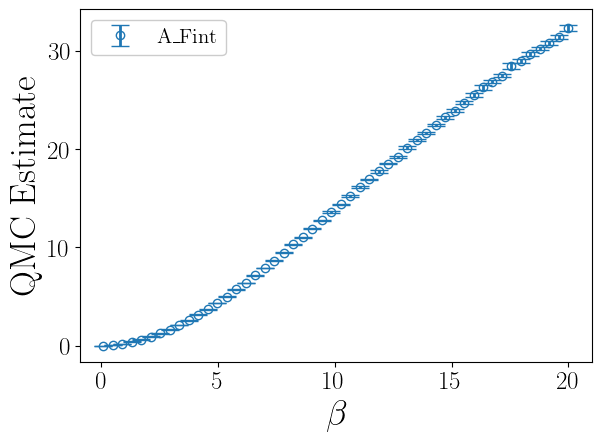

In [5]:
ebar_size = 6.5
height = 5
width = height * 1.618
k = 0
for obs in ["A_Fint"]:
    x = df["beta"]
    if obs in ["A_Eint", "A_Fint"]:
        y = df[f"total_mean_{obs}"]
        yerr = 2 * df[f"total_std_{obs}"] 
    else:
        y = df[f"total_mean_{obs}"]
        yerr = 2 * df[f"total_std_{obs}"]
    color = f"C{k}"
    plt.errorbar(x=x, y=y, yerr=yerr, fmt='o', capsize=ebar_size, 
                 markerfacecolor='none', markeredgecolor=color, ecolor=color, label=obs)
    k +=1 
    
# Set labels with larger fonts
plt.xlabel(r"$\beta$", fontsize=26)
plt.ylabel("QMC Estimate", fontsize=26)
#plt.legend(fontsize=18, loc=(0.01,0.37))
plt.legend(fontsize=15)

# Adjust tick parameters
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)

# Optimize layout for readability
plt.tight_layout(pad=1)  

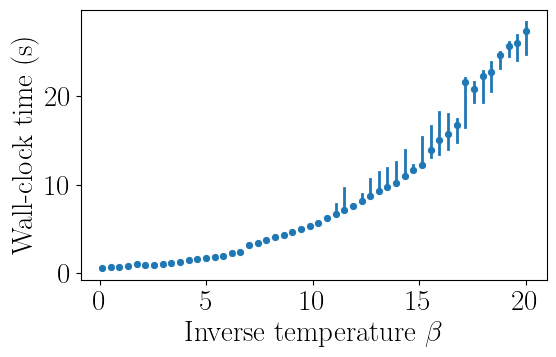

In [6]:
# Identify columns like elapsed_time_rank0 ... rank5
rank_cols = [c for c in df.columns if c.startswith("elapsed_time_rank")]

# Melt into long form
df_long = df.melt(
    id_vars=["beta"],            # keep beta as-is
    value_vars=rank_cols,        # the rank columns
    var_name="rank",             # new column: 'rank'
    value_name="elapsed_time",   # new column: each time
)

# Extract rank number (0,1,...5) as an integer
df_long["rank"] = df_long["rank"].str.extract(r"(\d+)").astype(int)

fig, ax = plt.subplots(figsize=(6,4))

sns.lineplot(
    data=df_long,
    x="beta",
    y="elapsed_time",
    estimator="median",      # center = median
    errorbar=("pi", 95),     # percentile interval 2.5–97.5
    err_style="bars",        # or "band"
    marker="o",
    linestyle="",
    ax=ax
)

ax.set_xlabel(r"Inverse temperature $\beta$")
ax.set_ylabel("Wall-clock time (s)")
ax.grid(False)

plt.tight_layout()
plt.show()